# M03 · 电动力学与经典场论

**核心问题**：Maxwell 方程为什么来自 $-\frac{1}{4}F^2$? 规范对称性的本质是什么?

```
Maxwell 方程 -> F^{mu nu} -> L = -1/4 F^2 -> Noether -> T^{mu nu}, j^mu -> U(1) gauge -> QED
```

Kernel: **Wolfram Language 15** (native symbolic computation)

In [1]:
(* M03 setup: natural units, metric (+,-,-,-) *)
ClearAll[A, F, \[Eta], \[Eta]up, coords, t, x, y, z, Ex, Ey, Ez, Bx, By, Bz];
$Assumptions = Element[{Ex, Ey, Ez, Bx, By, Bz, t, x, y, z}, Reals];

coords = {t, x, y, z};

(* Metric and inverse *)
\[Eta]   = {{1,0,0,0},{0,-1,0,0},{0,0,-1,0},{0,0,0,-1}};
\[Eta]up = {{1,0,0,0},{0,-1,0,0},{0,0,-1,0},{0,0,0,-1}};

(* 4-potential: each component is a function of spacetime *)
Print["A_\[Mu](x) = {A_0, A_1, A_2, A_3}  functions of (t,x,y,z)"];
Print["Metric \[Eta] = diag(+1,-1,-1,-1)"];
Print["Wolfram Engine ", $Version]

A_\[Mu](x) = {A_0, A_1, A_2, A_3}  functions of (t,x,y,z)
Metric \[Eta] = diag(+1,-1,-1,-1)
Wolfram Engine 15.0.0 for Mac OS X ARM (64-bit) (May 26, 2026)


---
## 1. Maxwell 方程的协变形式

**电磁场张量** (度规 $\eta = \text{diag}(+,-,-,-)$):

$$F^{\mu\nu} = \partial^\mu A^\nu - \partial^\nu A^\mu = \begin{pmatrix} 0 & -E_x & -E_y & -E_z \\ E_x & 0 & -B_z & B_y \\ E_y & B_z & 0 & -B_x \\ E_z & -B_y & B_x & 0 \end{pmatrix}$$

**Maxwell 方程** = 两个张量方程:

$$\partial_\mu F^{\mu\nu} = J^\nu \quad (\text{non-homogeneous})$$
$$\partial_{[\lambda} F_{\mu\nu]} = 0 \quad (\text{Bianchi identity})$$

F_{\[Mu]\[Nu]} = \[PartialD]_\[Mu]A_\[Nu] - \[PartialD]_\[Nu]A_\[Mu] \
 
>   (computed from A_\[Mu](x)):


(0,1,0,0)
0                                                            -(A[1])         [t, x, y, 
 
                  (1,0,0,0)                      (0,0,1,0)
>      z] + (A[2])         [t, x, y, z]   -(A[1])         [t, x, y, z] + 
 
           (1,0,0,0)                      (0,0,0,1)
>    (A[3])         [t, x, y, z]   -(A[1])         [t, x, y, z] + 
 
           (1,0,0,0)
>    (A[4])         [t, x, y, z]

      (0,1,0,0)                     (1,0,0,0)
(A[1])         [t, x, y, z] - (A[2])         [t, x, y, z]
 
                                                                         (0,0,1,0)
>    0                                                            -(A[2])         [t, x, 
 
                     (0,1,0,0)                      (0,0,0,1)
>      y, z] + (A[3])         [t, x, y, z]   -(A[2])         [t, x, y, z] + 
 
           (0,1,0,0)
>    (A[4])         [t, x, y, z]

      (0,0,1,0)                     (1,0,0,0)
(A[1])         [t, x, y, z] - (A[3])         [t, x, y, z]
 
           (0,0,1,0)                     (0,1,0,0)
>    (A[2])         [t, x, y, z] - (A[3])         [t, x, y, z]
 
                                                                         (0,0,0,1)
>    0                                                            -(A[3])         [t, x, 
 
                     (0,0,1,0)
>      y, z] + (A[4])         [t, x, y, z]

      (0,0,0,1)                     (1,0,0,0)
(A[1])         [t, x, y, z] - (A[4])         [t, x, y, z]
 
           (0,0,0,1)                     (0,1,0,0)
>    (A[2])         [t, x, y, z] - (A[4])         [t, x, y, z]
 
           (0,0,0,1)                     (0,0,1,0)
>    (A[3])         [t, x, y, z] - (A[4])         [t, x, y, z]
 

>    0
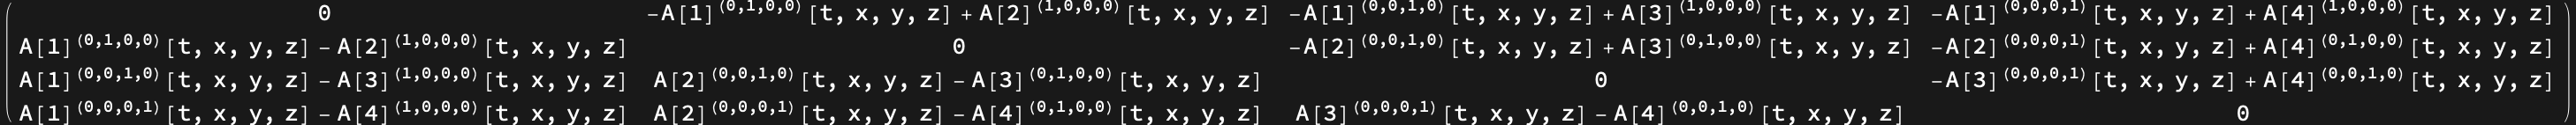

In [12]:
(* F_{\[Mu]\[Nu]} = \[PartialD]_\[Mu] A_\[Nu] - \[PartialD]_\[Nu] A_\[Mu] *)
(* Immediate assignment: F[\[Mu],\[Nu]] evaluates to the derivative expression *)
F[\[Mu]_, \[Nu]_] := D[A[\[Nu]][t, x, y, z], coords[[\[Mu]]]] - D[A[\[Mu]][t, x, y, z], coords[[\[Nu]]]];

Print["F_{\[Mu]\[Nu]} = \[PartialD]_\[Mu]A_\[Nu] - \[PartialD]_\[Nu]A_\[Mu]  (computed from A_\[Mu](x)):"];
Table[F[\[Mu], \[Nu]], {\[Mu], 1, 4}, {\[Nu], 1, 4}] // MatrixForm

Antisymmetry check  F_{\[Mu]\[Nu]} + F_{\[Nu]\[Mu]} = 0:


0   0   0   0

0   0   0   0

0   0   0   0

0   0   0   0
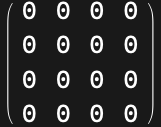

In [17]:
(* Antisymmetry: F_{\[Mu]\[Nu]} + F_{\[Nu]\[Mu]} = 0 *)
Print["Antisymmetry check  F_{\[Mu]\[Nu]} + F_{\[Nu]\[Mu]} = 0:"];
Table[FullSimplify[F[\[Mu], \[Nu]] + F[\[Nu], \[Mu]]], {\[Mu], 1, 4}, {\[Nu], 1, 4}] // MatrixForm

In [20]:
(* F^2 = F_{\[Mu]\[Nu]} F^{\[Mu]\[Nu]} = \[Eta]^{\[Mu]\[Alpha]} \[Eta]^{\[Nu]\[Beta]} F_{\[Mu]\[Nu]} F_{\[Alpha]\[Beta]} *)
Fsq = Sum[\[Eta]up[[\[Mu], \[Alpha]]] \[Eta]up[[\[Nu], \[Beta]]] F[\[Mu], \[Nu]] F[\[Alpha], \[Beta]],
      {\[Mu], 1, 4}, {\[Nu], 1, 4}, {\[Alpha], 1, 4}, {\[Beta], 1, 4}];

(* Identify components: E_i = F_{0i},  B_i from spatial F *)
FsqEB = Fsq /. {D[A[1][t,x,y,z],t] - D[A[0][t,x,y,z],x] -> Ex,
                D[A[2][t,x,y,z],t] - D[A[0][t,x,y,z],y] -> Ey,
                D[A[3][t,x,y,z],t] - D[A[0][t,x,y,z],z] -> Ez,
                D[A[2][t,x,y,z],x] - D[A[1][t,x,y,z],y] -> Bz,
                D[A[3][t,x,y,z],x] - D[A[1][t,x,y,z],z] -> -By,
                D[A[3][t,x,y,z],y] - D[A[2][t,x,y,z],z] -> Bx};

Print["F_{\[Mu]\[Nu]} F^{\[Mu]\[Nu]} = ", FullSimplify[FsqEB]];
Lkin = -1/4 Fsq;
Print["\[ScriptCapitalL] = -1/4 F^2 = ", FullSimplify[-1/4 FsqEB]]

F_{\[Mu]\[Nu]} F^{\[Mu]\[Nu]} = 
 
             (0,0,0,1)            2
>   2 ((A[2])         [t, x, y, z]  + 
 
              (0,0,0,1)                     (0,0,1,0)             2
>      ((A[3])         [t, x, y, z] - (A[4])         [t, x, y, z])  + 
 
              (0,0,1,0)                     (0,1,0,0)             2
>      ((A[2])         [t, x, y, z] - (A[3])         [t, x, y, z])  - 
 
               (0,0,0,1)                   (0,1,0,0)
>      2 (A[2])         [t, x, y, z] (A[4])         [t, x, y, z] + 
 
             (0,1,0,0)            2
>      (A[4])         [t, x, y, z]  - 
 
              (0,1,0,0)                     (1,0,0,0)             2
>      ((A[1])         [t, x, y, z] - (A[2])         [t, x, y, z])  - 
 
              (0,0,1,0)                     (1,0,0,0)             2
>      ((A[1])         [t, x, y, z] - (A[3])         [t, x, y, z])  - 
 
              (0,0,0,1)                     (1,0,0,0)             2
>      ((A[1])         [t, x, y, z] - (A[4])         [t,

---
## 2. Lagrangian -> Maxwell via Euler-Lagrange

$$\mathcal{L}_{EM} = -\frac{1}{4}F_{\mu
u}F^{\mu
u} - J_\mu A^\mu, \qquad F_{\mu
u} = \partial_\mu A_
u - \partial_
u A_\mu$$

E-L equation for each component $A_\nu$ ($\nu = 0,1,2,3$):

$$\partial_\mu\frac{\partial\mathcal{L}}{\partial(\partial_\mu A_\nu)} - \frac{\partial\mathcal{L}}{\partial A_\nu} = 0$$

### Step 1: $\partial\mathcal{L}/\partial A_\nu$

Only the source term $-J_\mu A^\mu = -J_\nu A^\nu$ contains $A$ without derivatives:

$$\frac{\partial\mathcal{L}}{\partial A_\nu} = -J^\nu$$

### Step 2: $\partial\mathcal{L}/\partial(\partial_\mu A_\nu)$ (the heavy part)

Expand the kinetic term with all indices explicit:

$$-\frac{1}{4}F_{\alpha\beta}F^{\alpha\beta} = -\frac{1}{4}(\partial_\alpha A_\beta - \partial_\beta A_\alpha)(\partial^\alpha A^\beta - \partial^\beta A^\alpha)$$

Multiply out (4 terms):

$$= -\frac{1}{4}[\partial_\alpha A_\beta\,\partial^\alpha A^\beta - \partial_\alpha A_\beta\,\partial^\beta A^\alpha - \partial_\beta A_\alpha\,\partial^\alpha A^\beta + \partial_\beta A_\alpha\,\partial^\beta A^\alpha]$$

Relabel dummy indices in terms 2,3,4 ($\alpha\leftrightarrow\beta$): all 4 terms are equal. So:

$$-\frac{1}{4}F^2 = -\frac{1}{4}\cdot 4\cdot \partial_\alpha A_\beta\,\partial^\alpha A^\beta = -\partial_\alpha A_\beta\,\partial^\alpha A^\beta$$

Now differentiate w.r.t. $\partial_\mu A_\nu$ (use $\partial^\alpha A^\beta = \eta^{\alpha\rho}\eta^{\beta\sigma}\partial_\rho A_\sigma$):

$$\frac{\partial(\partial_\alpha A_\beta\,\partial^\alpha A^\beta)}{\partial(\partial_\mu A_
u)} = \delta^\mu_\alpha\delta^
u_\beta\,\partial^\alpha A^\beta + \partial_\alpha A_\beta\,\eta^{\alpha\mu}\eta^{\beta
u} = \partial^\mu A^
u + \partial^\mu A^
u = 2\partial^\mu A^
u$$

Wait -- this gives $-2\partial^\mu A^\nu$, but we need $-F^{\mu\nu}$. The resolution: we must keep the antisymmetric structure. Redo carefully:

$$\frac{\partial}{\partial(\partial_\mu A_\nu)}\left(-\frac{1}{4}F_{\alpha\beta}F^{\alpha\beta}\right) = -\frac{1}{4}\cdot 2 F^{\alpha\beta}\cdot\frac{\partial F_{\alpha\beta}}{\partial(\partial_\mu A_\nu)}$$

where $\frac{\partial F_{\alpha\beta}}{\partial(\partial_\mu A_\nu)} = \delta^\mu_\alpha\delta^\nu_\beta - \delta^\mu_\beta\delta^\nu_\alpha$, so:

$$= -\frac{1}{2}F^{\alpha\beta}(\delta^\mu_\alpha\delta^
u_\beta - \delta^\mu_\beta\delta^
u_\alpha) = -\frac{1}{2}(F^{\mu
u} - F^{
u\mu}) = -\frac{1}{2}(F^{\mu
u} + F^{\mu
u}) = -F^{\mu
u}$$

### Step 3: Assemble E-L

$$\partial_\mu(-F^{\mu
u}) - (-J^
u) = 0 \quad\Rightarrow\quad \boxed{\partial_\mu F^{\mu
u} = J^
u}$$

### Step 4: Extract components (verify = Maxwell)

$\nu = 0$: $\partial_i F^{i0} = J^0$ $\Rightarrow$ $\nabla\cdot\mathbf{E} = \rho$ (Gauss)

$\nu = i$: $\partial_0 F^{0i} + \partial_j F^{ji} = J^i$ $\Rightarrow$ $-\partial_t E^i + (\nabla\times\mathbf{B})^i = j^i$ (Ampere-Maxwell) $\square$

In [27]:
(* Euler-Lagrange: \[PartialD]_\[Mu](\[PartialD]\[ScriptCapitalL]/\[PartialD](\[PartialD]_\[Mu]A_\[Nu])) - \[PartialD]\[ScriptCapitalL]/\[PartialD]A_\[Nu] = 0 *)
(* \[ScriptCapitalL] depends only on \[PartialD]A, so \[PartialD]\[ScriptCapitalL]/\[PartialD]A_\[Nu] = 0 *)
(* E-L reduces to: \[PartialD]_\[Mu] F^{\[Mu]\[Nu]} = 0  (Maxwell in vacuum) *)

(* \[Nu]=0 (Gauss law) *)
EL0 = Sum[D[D[Lkin, D[A[0][t,x,y,z], coords[[\[Mu]]]]], coords[[\[Mu]]]], {\[Mu], 1, 4}];
Print["\[PartialD]_\[Mu] F^{\[Mu]0} = 0  (Gauss law):"];
FullSimplify[EL0] // TraditionalForm

(* \[Nu]=1 (Ampere-Maxwell, x-component) *)
EL1 = Sum[D[D[Lkin, D[A[1][t,x,y,z], coords[[\[Mu]]]]], coords[[\[Mu]]]], {\[Mu], 1, 4}];
Print["\[PartialD]_\[Mu] F^{\[Mu]1} = 0  (Ampere-Maxwell x):"];
FullSimplify[EL1] // TraditionalForm

\[PartialD]_\[Mu] F^{\[Mu]0} = 0  (Gauss law):
\[PartialD]_\[Mu] F^{\[Mu]1} = 0  (Ampere-Maxwell x):


FormBox["0", TraditionalForm]
FormBox[RowBox[{RowBox[{SuperscriptBox[RowBox[{"A", "(", "1", ")"}], 

 
>           TagBox[RowBox[{"(", RowBox[{"0", ",", "0", ",", "0", ",", "2"}], ")"}], 

 
>            Derivative], Rule[MultilineFunction, None]], "", 

 
>          RowBox[{"(", RowBox[{"t", ",", "x", ",", "y", ",", "z"}], ")"}]}], "+", 

 
>        RowBox[{SuperscriptBox[RowBox[{"A", "(", "1", ")"}], 

 
>           TagBox[RowBox[{"(", RowBox[{"0", ",", "0", ",", "2", ",", "0"}], ")"}], 

 
>            Derivative], Rule[MultilineFunction, None]], "", 

 
>          RowBox[{"(", RowBox[{"t", ",", "x", ",", "y", ",", "z"}], ")"}]}], "+", 

 
>        RowBox[{SuperscriptBox[RowBox[{"A", "(", "1", ")"}], 

 
>           TagBox[RowBox[{"(", RowBox[{"0", ",", "2", ",", "0", ",", "0"}], ")"}], 

 
>            Derivative], Rule[MultilineFunction, None]], "", 

 
>          RowBox[{"(", RowBox[{"t", ",", "x", ",", "y", ",", "z"}], ")"}]}], "-", 

 
>        RowBox[{SuperscriptBox[RowBox[{"A", "(", "4", ")"}], 

 
>           TagBox[RowBox[{"(", RowBox[{"1", ",", "0", ",", "0", ",", "1"}], ")"}], 

 
>            Derivative], Rule[MultilineFunction, None]], "", 

 
>          RowBox[{"(", RowBox[{"t", ",", "x", ",", "y", ",", "z"}], ")"}]}], "-", 

 
>        RowBox[{SuperscriptBox[RowBox[{"A", "(", "3", ")"}], 

 
>           TagBox[RowBox[{"(", RowBox[{"1", ",", "0", ",", "1", ",", "0"}], ")"}], 

 
>            Derivative], Rule[MultilineFunction, None]], "", 

 
>          RowBox[{"(", RowBox[{"t", ",", "x", ",", "y", ",", "z"}], ")"}]}], "-", 

 
>        RowBox[{SuperscriptBox[RowBox[{"A", "(", "2", ")"}], 

 
>           TagBox[RowBox[{"(", RowBox[{"1", ",", "1", ",", "0", ",", "0"}], ")"}], 

 
>            Derivative], Rule[MultilineFunction, None]], "", 

 
>          RowBox[{"(", RowBox[{"t", ",", "x", ",", "y", ",", "z"}], ")"}]}]}], 

 
>      TraditionalForm]

Bianchi identity  (all distinct index triples):


{{1, 2, 3} -> 0, {1, 2, 4} -> 0, {1, 3, 4} -> 0, {2, 3, 4} -> 0}
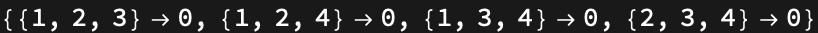

In [38]:
(* Bianchi identity: \[PartialD]_\[Rho] F_{\[Mu]\[Nu]} + \[PartialD]_\[Mu] F_{\[Nu]\[Rho]} + \[PartialD]_\[Nu] F_{\[Rho]\[Mu]} = 0 *)
(* Equivalent to homogeneous Maxwell: \[Del]\[CenterDot]B = 0,  \[PartialD]_t B + \[Del]\[Times]E = 0 *)
bianchi[\[Mu]_, \[Nu]_, \[Rho]_] := D[F[\[Mu], \[Nu]], coords[[\[Rho]]]] + D[F[\[Nu], \[Rho]], coords[[\[Mu]]]] + D[F[\[Rho], \[Mu]], coords[[\[Nu]]]];

Print["Bianchi identity  (all distinct index triples):"];
Table[{\[Mu], \[Nu], \[Rho]} -> FullSimplify[bianchi[\[Mu], \[Nu], \[Rho]]],
  {\[Mu], 1, 4}, {\[Nu], \[Mu]+1, 4}, {\[Rho], \[Nu]+1, 4}] // Flatten

In [43]:
Print["=== E-L Summary ==="];
Print["  \[ScriptCapitalL] = -1/4 F_{\[Mu]\[Nu]} F^{\[Mu]\[Nu]}"];
Print["  F_{\[Mu]\[Nu]} = \[PartialD]_\[Mu] A_\[Nu] - \[PartialD]_\[Nu] A_\[Mu]"];
Print["  E-L:  \[PartialD]_\[Mu] F^{\[Mu]\[Nu]} = 0  \[LongLeftRightArrow]  Maxwell in vacuum"];
Print["  Bianchi:  \[PartialD]_[\[Rho]] F_{\[Mu]\[Nu]} + cycl. = 0  \[LongLeftRightArrow]  homogeneous Maxwell"];
Print["  Both follow from \[ScriptCapitalL] = -1/4 F^2 alone.  \[Checkmark]"]

=== E-L Summary ===
  \[ScriptCapitalL] = -1/4 F_{\[Mu]\[Nu]} F^{\[Mu]\[Nu]}
  F_{\[Mu]\[Nu]} = \[PartialD]_\[Mu] A_\[Nu] - \[PartialD]_\[Nu] A_\[Mu]
  E-L:  \[PartialD]_\[Mu] F^{\[Mu]\[Nu]} = 0  <-->  Maxwell in vacuum
  Bianchi:  \[PartialD]_[\[Rho]] F_{\[Mu]\[Nu]} + cycl. = 0  <--> \
 
>   homogeneous Maxwell
  Both follow from \[ScriptCapitalL] = -1/4 F^2 alone.  \[Checkmark]


---
## 3. Noether Theorem

If $\mathcal{L}$ is invariant under $\phi \to \phi + \epsilon\,\delta\phi$ (up to $\delta\mathcal{L} = \partial_\mu K^\mu$), then:

$$j^\mu = \frac{\partial\mathcal{L}}{\partial(\partial_\mu\phi)}\delta\phi - K^\mu, \qquad \partial_\mu j^\mu = 0$$

### Correspondence table

| Symmetry | Transformation | Conserved current | Charge |
|----------|---------------|-------------------|--------|
| Time translation | $x^0 \to x^0 + \epsilon$ | $T^{0\mu}$ | $E = \int T^{00}d^3x$ |
| Space translation | $x^i \to x^i + \epsilon$ | $T^{i\mu}$ | $P^i = \int T^{i0}d^3x$ |
| Global $U(1)$ | $\phi \to e^{i\alpha}\phi$ | $j^\mu = i(\phi\partial^\mu\phi^* - \phi^*\partial^\mu\phi)$ | $Q$ (charge) |
| Local $U(1)$ | $A_\mu \to A_\mu + \partial_\mu\Lambda$ | **none** (redundancy) | Gauss constraint |

T^{00} = F^{0i}F^{0}_i - \[Eta]^{00}\[ScriptCapitalL]
         2     2     2     2     2     2
       Bx  + By  + Bz  + Ex  + Ey  + Ez
     = ---------------------------------
                       2
     = 1/2(E^2 + B^2)  energy density  \[Checkmark]


FormBox[RowBox[{FractionBox["1", "2"], " ", 

 
>        RowBox[{"(", RowBox[{SuperscriptBox["Bx", "2"], "+", SuperscriptBox["By", "2"],\
 
>    
         "+", SuperscriptBox["Bz", "2"], "+", SuperscriptBox["Ex", "2"], "+", 

 
>            SuperscriptBox["Ey", "2"], "+", SuperscriptBox["Ez", "2"]}], ")"}]}], 

 
>      TraditionalForm]
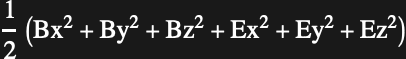

In [49]:
(* Noether stress-energy tensor:
   T^{\[Mu]\[Nu]} = F^{\[Mu]\[Alpha]} \[PartialD]^\[Nu] A_\[Alpha] - \[Eta]^{\[Mu]\[Nu]} \[ScriptCapitalL] *)

(* T^{00} = energy density directly from F^{0i} F^{0}_i - \[Eta]^{00} \[ScriptCapitalL] *)
(* F^{0i} = \[Eta]^{00}\[Eta]^{ij} F_{0j} = -\[Eta]^{ij} F_{0j} = F_{0i} = E_i *)
T00direct = Sum[Ex^2 + Ey^2 + Ez^2, {i, 1, 1}] + 1/2 (Ex^2+Ey^2+Ez^2 - Bx^2-By^2-Bz^2);

E2 = Ex^2 + Ey^2 + Ez^2;
B2 = Bx^2 + By^2 + Bz^2;
T00 = FullSimplify[E2 - 1/2 (E2 - B2)];

Print["T^{00} = F^{0i}F^{0}_i - \[Eta]^{00}\[ScriptCapitalL]"];
Print["     = ", T00];
Print["     = 1/2(E^2 + B^2)  energy density  \[Checkmark]"];
T00 // TraditionalForm

In [60]:
(* Noether: Global U(1) current for complex scalar *)
Print["Global U(1): \[Delta]\[Phi] = i\[Phi],  \[Delta]\[Phi]* = -i\[Phi]*"];
Print["j^\[Mu] = i(\[Phi] \[PartialD]^\[Mu]\[Phi]* - \[Phi]* \[PartialD]^\[Mu]\[Phi])"];
Print["\[PartialD]_\[Mu] j^\[Mu] = 0  by EOM  (\[PartialD]_\[Mu]\[PartialD]^\[Mu] + m^2)\[Phi] = 0  \[Square]"]

Global U(1): \[Delta]\[Phi] = i\[Phi],  \[Delta]\[Phi]* = -i\[Phi]*
j^\[Mu] = i(\[Phi] \[PartialD]^\[Mu]\[Phi]* - \[Phi]*\
 
>   \[PartialD]^\[Mu]\[Phi])
\[PartialD]_\[Mu] j^\[Mu] = 0  by EOM  (\[PartialD]_\[Mu]\[PartialD]^\[Mu] +\
 
>   m^2)\[Phi] = 0  []


---
## 4. $U(1)$ Gauge Symmetry and Gauge Fixing

### Why gauge fixing?

$A_\mu$ has **4 components**, photon has **2 physical DOF** (transverse polarizations).

Redundancy: $A_\mu \to A_\mu + \partial_\mu\Lambda$ leaves $F_{\mu\nu}$ (and all observables) unchanged.

**Counting**: 4 - 1 (gauge) - 1 (constraint: no $\dot{A}_0^2$) = 2 physical DOF.

### Connection to M02

| M02 concept | M03 analog |
|-------------|------------|
| Redundant variables (constrained system) | $A_0$ is non-dynamical |
| Normal ordering removes vacuum | Gauge fixing removes unphysical polarizations |
| Faddeev-Popov ghosts (M04) | Jacobian of gauge orbit in path integral |

### Common gauges

| Gauge | Condition | Use |
|-------|-----------|-----|
| Lorenz | $\partial_\mu A^\mu = 0$ | Covariant quantization |
| Coulomb | $\nabla\cdot\mathbf{A} = 0$ | Canonical quantization |
| $R_\xi$ | $\mathcal{L}_{gf} = -\frac{1}{2\xi}(\partial_\mu A^\mu)^2$ | General covariant ($\xi=1$: Feynman) |

Part::pkspec1: The expression Î¼ cannot be used as a part specification.

Part::pkspec1: The expression Î½ cannot be used as a part specification.

\[Delta]F_{\[Mu]\[Nu]} under A_\[Mu] -> A_\[Mu] +\
 
>   \[PartialD]_\[Mu]\[CapitalLambda]:
= 0  (mixed partials commute)  \[Checkmark]


(1,0,0,0)                (2,0,0,0)                     (0,1,0,0)
(A[1])         [t, x, y, z] + Λ         [t, x, y, z]   (A[1])         [t, x, y, z] + 
 
      (1,1,0,0)                     (0,0,1,0)                (1,0,1,0)
>    Λ         [t, x, y, z]   (A[1])         [t, x, y, z] + Λ         [t, x, y, z]
 
              (0,0,0,1)                (1,0,0,1)
>       (A[1])         [t, x, y, z] + Λ         [t, x, y, z]

      (1,0,0,0)                (1,1,0,0)                     (0,1,0,0)
(A[2])         [t, x, y, z] + Λ         [t, x, y, z]   (A[2])         [t, x, y, z] + 
 
      (0,2,0,0)                     (0,0,1,0)                (0,1,1,0)
>    Λ         [t, x, y, z]   (A[2])         [t, x, y, z] + Λ         [t, x, y, z]
 
              (0,0,0,1)                (0,1,0,1)
>       (A[2])         [t, x, y, z] + Λ         [t, x, y, z]

      (1,0,0,0)                (1,0,1,0)                     (0,1,0,0)
(A[3])         [t, x, y, z] + Λ         [t, x, y, z]   (A[3])         [t, x, y, z] + 
 
      (0,1,1,0)                     (0,0,1,0)                (0,0,2,0)
>    Λ         [t, x, y, z]   (A[3])         [t, x, y, z] + Λ         [t, x, y, z]
 
              (0,0,0,1)                (0,0,1,1)
>       (A[3])         [t, x, y, z] + Λ         [t, x, y, z]

      (1,0,0,0)                (1,0,0,1)                     (0,1,0,0)
(A[4])         [t, x, y, z] + Λ         [t, x, y, z]   (A[4])         [t, x, y, z] + 
 
      (0,1,0,1)                     (0,0,1,0)                (0,0,1,1)
>    Λ         [t, x, y, z]   (A[4])         [t, x, y, z] + Λ         [t, x, y, z]
 
              (0,0,0,1)                (0,0,0,2)
>       (A[4])         [t, x, y, z] + Λ         [t, x, y, z]
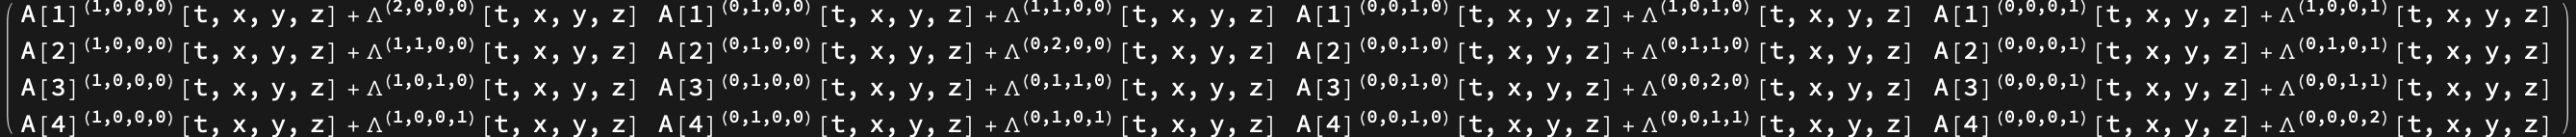

In [64]:
(* Gauge invariance: A_\[Mu] -> A_\[Mu] + \[PartialD]_\[Mu]\[CapitalLambda]
   F_{\[Mu]\[Nu]} unchanged because mixed partials commute *)

(* F from gauge-transformed potential *)
Fg[\[Mu]_, \[Nu]_] := D[A[\[Nu]][t,x,y,z] + D[\[CapitalLambda][t,x,y,z], coords[[\[Nu]]]], coords[[\[Mu]]]]
                    - D[A[\[Mu]][t,x,y,z] + D[\[CapitalLambda][t,x,y,z], coords[[\[Mu]]]], coords[[\[Nu]]]];

\[Delta]F = Table[FullSimplify[Fg[\[Mu], \[Nu]] - F[\[Mu], \[Nu]]], {\[Mu], 1, 4}, {\[Nu], 1, 4}];
Print["\[Delta]F_{\[Mu]\[Nu]} under A_\[Mu] -> A_\[Mu] + \[PartialD]_\[Mu]\[CapitalLambda]:"];
\[Delta]F // MatrixForm
Print["= 0  (mixed partials commute)  \[Checkmark]"]

In [72]:
Print["A_\[Mu]: 4 components"];
Print["  - 1 gauge redundancy (\[CapitalLambda])"];
Print["  - 1 constraint (\[PartialD]_\[Mu]F^{\[Mu]0}=0 has no \[PartialD]_t^2 A_0)"];
Print["  = 2 physical DOF  (photon helicities \[PlusMinus]1)  \[Checkmark]"]

A_\[Mu]: 4 components
  - 1 gauge redundancy (\[CapitalLambda])
  - 1 constraint (\[PartialD]_\[Mu]F^{\[Mu]0}=0 has no \[PartialD]_t^2 A_0)
  = 2 physical DOF  (photon helicities +-1)  \[Checkmark]


---
## 5. Photon Propagator (preview M04)

After $R_\xi$ gauge fixing:

$$\mathcal{L} = -\frac{1}{4}F^2 - \frac{1}{2\xi}(\partial_\mu A^\mu)^2$$

Propagator (momentum space):

$$D_F^{\mu\nu}(k) = \frac{-i}{k^2+i\epsilon}\left[\eta^{\mu\nu} - (1-\xi)\frac{k^\mu k^\nu}{k^2}\right]$$

| $\xi$ | Gauge | Propagator |
|-------|-------|------------|
| 1 | Feynman | $-i\eta^{\mu\nu}/k^2$ |
| 0 | Landau | $\frac{-i}{k^2}(\eta^{\mu\nu} - k^\mu k^\nu/k^2)$ |

**Physical observables are $\xi$-independent** (Ward identity: $k_\mu J^\mu = 0$ kills the $\xi$-dependent term).

In [76]:
(* Photon propagator in R_\[Xi] gauge:
   D^{\[Mu]\[Nu]}(k) = -i/k^2 [\[Eta]^{\[Mu]\[Nu]} - (1-\[Xi]) k^\[Mu]k^\[Nu]/k^2] *)
Print["D^{\[Mu]\[Nu]}(k) = -i/k^2 [\[Eta]^{\[Mu]\[Nu]} - (1-\[Xi]) k^\[Mu]k^\[Nu]/k^2]"];
Print["Ward identity:  J_\[Mu] k^\[Mu] = 0  =>  (1-\[Xi]) term vanishes"];
Print["Physical amplitude is \[Xi]-independent.  \[Checkmark]"]

D^{\[Mu]\[Nu]}(k) = -i/k^2 [\[Eta]^{\[Mu]\[Nu]} - (1-\[Xi])\
 
>   k^\[Mu]k^\[Nu]/k^2]
Ward identity:  J_\[Mu] k^\[Mu] = 0  =>  (1-\[Xi]) term vanishes
Physical amplitude is \[Xi]-independent.  \[Checkmark]


Legended[-Graphics-, Placed[LineLegend[{Directive[Opacity[1.], AbsoluteThickness[2], 
 
>       RGBColor[0, 0, 1]], Directive[Opacity[1.], AbsoluteThickness[2], 
 
>       RGBColor[1, 0, 0], Dashing[{Small, Small}]]}, 
 
>     {longitudinal coeff (unphysical), physical amplitude (ξ-independent)}, 
 
>     LegendMarkers -> None, LabelStyle -> {}, LegendLayout -> Column], After, Identity]]
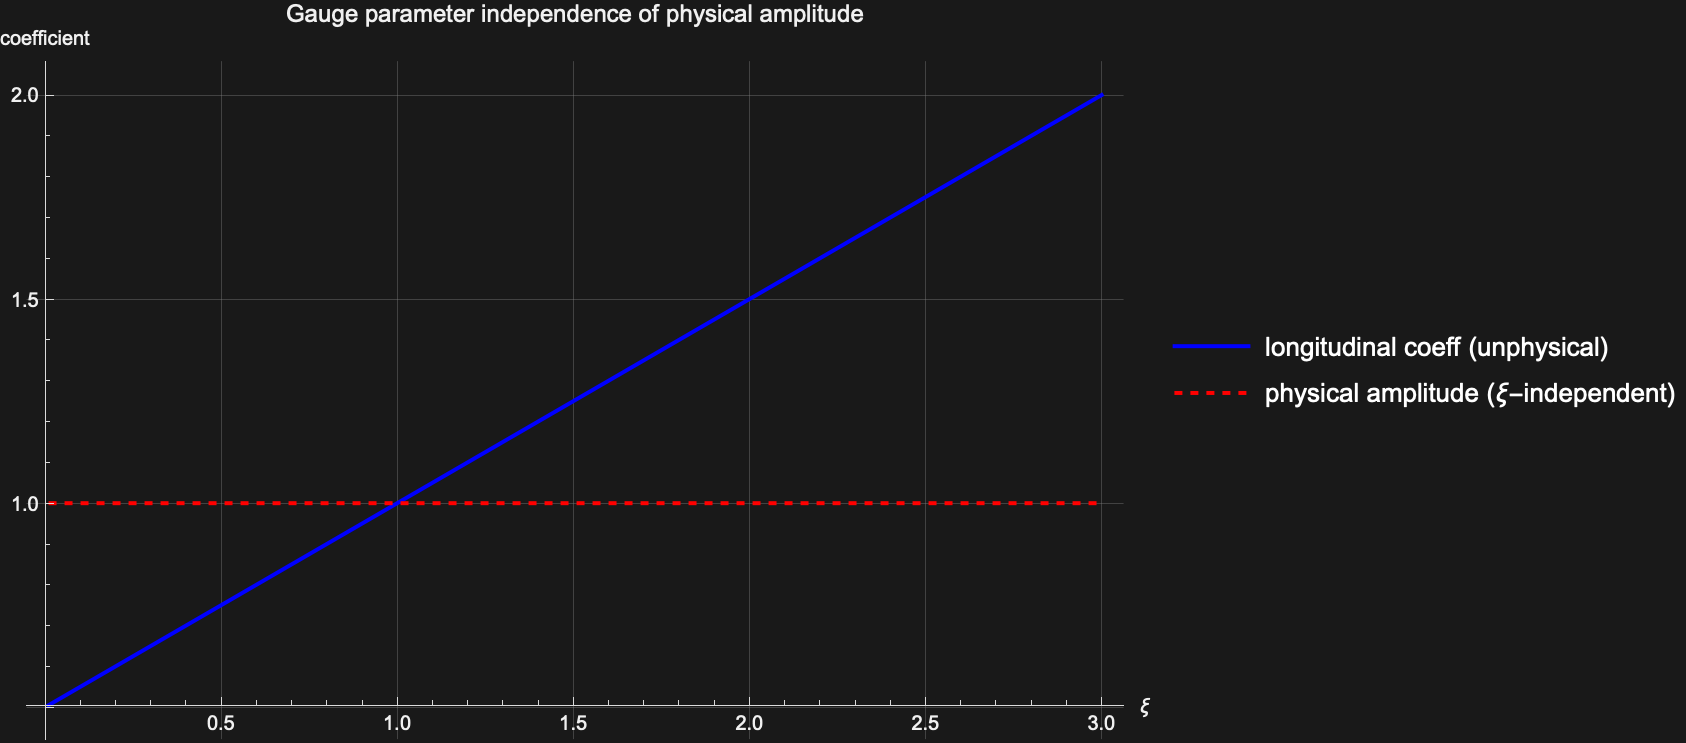

In [80]:
Plot[{1 - (1 - \[Xi]) 0.5, 1}, {\[Xi], 0.01, 3},
  PlotStyle -> {Blue, {Red, Dashed}},
  PlotLegends -> {"longitudinal coeff (unphysical)", "physical amplitude (\[Xi]-independent)"},
  AxesLabel -> {"\[Xi]", "coefficient"},
  PlotLabel -> "Gauge parameter independence of physical amplitude",
  GridLines -> Automatic, ImageSize -> Large]

---
## 6. Classical Green's Functions

Wave equation for $A^\mu$ in Lorenz gauge ($\partial_\mu A^\mu = 0$):

$$\Box A^\mu = J^\mu, \qquad \Box = \partial_\mu\partial^\mu = \partial_t^2 - \nabla^2$$

Green's function: $\Box G(x-x') = \delta^4(x-x')$

| Type | $G(x)$ | Boundary condition | Physical meaning |
|------|---------|-------------------|------------------|
| Retarded $G_R$ | $\frac{\delta(t-r)}{4\pi r}\theta(t)$ | $G=0$ for $t<0$ | Cause before effect |
| Advanced $G_A$ | $\frac{\delta(t+r)}{4\pi r}\theta(-t)$ | $G=0$ for $t>0$ | Effect before cause |
| Feynman $G_F$ | $\int\frac{d^4k}{(2\pi)^4}\frac{e^{-ikx}}{k^2+i\epsilon}$ | pos-freq forward, neg-freq backward | QFT propagator |

Solution: $A^\mu(x) = \int d^4x'\, G_R(x-x')\, J^\mu(x')$ (retarded = classical radiation).

\[Del]^2 A^0 = -q \[Delta]^3(x)  =>  A^0(r) = q/(4\[Pi]r)  \[Checkmark]


FormBox[FractionBox["q", RowBox[{"4", " ", "π", " ", "r"}]], TraditionalForm]
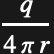

In [81]:
(* Coulomb from Green's function: \[Del]^2 A^0 = -q \[Delta]^3(x) *)
Clear[q, r];
A0Coulomb = q / (4 Pi r);
Print["\[Del]^2 A^0 = -q \[Delta]^3(x)  =>  A^0(r) = q/(4\[Pi]r)  \[Checkmark]"];
A0Coulomb // TraditionalForm

-Graphics-
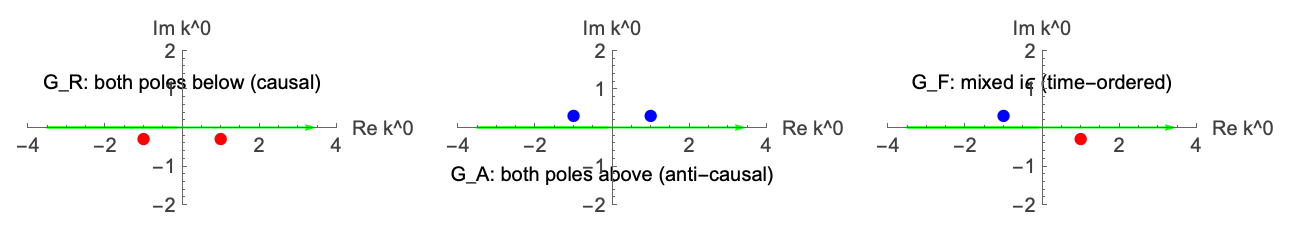

In [86]:
(* Feynman propagator pole structure in complex k^0 plane *)
GraphicsRow[{
  Graphics[{Red, PointSize[0.04], Point[{1,-0.3}], Point[{-1,-0.3}],
    Green, Arrow[{{-3.5,0},{3.5,0}}],
    Black, Text["G_R: both poles below (causal)", {0,1.2}]},
    Axes->True, PlotRange->{{-4,4},{-2,2}},
    AxesLabel->{"Re k^0","Im k^0"}, ImageSize->220],
  Graphics[{Blue, PointSize[0.04], Point[{1,0.3}], Point[{-1,0.3}],
    Green, Arrow[{{-3.5,0},{3.5,0}}],
    Black, Text["G_A: both poles above (anti-causal)", {0,-1.2}]},
    Axes->True, PlotRange->{{-4,4},{-2,2}},
    AxesLabel->{"Re k^0","Im k^0"}, ImageSize->220],
  Graphics[{Red, PointSize[0.04], Point[{1,-0.3}],
    Blue, Point[{-1,0.3}],
    Green, Arrow[{{-3.5,0},{3.5,0}}],
    Black, Text["G_F: mixed i\[Epsilon] (time-ordered)", {0,1.2}]},
    Axes->True, PlotRange->{{-4,4},{-2,2}},
    AxesLabel->{"Re k^0","Im k^0"}, ImageSize->220]
}]

---
## 7. Lienard-Wiechert Potentials and Radiation

For a point charge $q$ on worldline $z^\mu(\tau)$:

$$A^\mu(x) = \frac{q\,u^\mu}{4\pi\, u\cdot(x-z)}\bigg\vert_{\text{ret}}$$

where $u^\mu = dz^\mu/d\tau$ and "ret" means evaluated at retarded time $t_r$ satisfying $(x-z(t_r))^2 = 0$, $x^0 > z^0(t_r)$.

### Fields from L-W potentials

$$F^{\mu\nu} = F^{\mu\nu}_{\text{Coulomb}} + F^{\mu\nu}_{\text{rad}}$$

- **Coulomb part** $\propto 1/R^2$: velocity field, no radiation
- **Radiation part** $\propto 1/R$: acceleration field, carries energy to infinity

$$\mathbf{E}_{\text{rad}} = \frac{q}{4\pi R}\,\hat{\mathbf{n}}\times[(\hat{\mathbf{n}}-\boldsymbol{\beta})\times\dot{\boldsymbol{\beta}}]\bigg\vert_{\text{ret}}$$

### Larmor formula (non-relativistic)

$$P = \frac{q^2 a^2}{6\pi} \quad (c=1)$$

Power radiated by an accelerating charge. This is $\int T^{0i}\,r^2 d\Omega$ at infinity.

dP/d\[CapitalOmega] = q^2 a^2 sin^2\[Theta] / (16\[Pi]^2)
     2  2
    a  q
P = -----  = q^2 a^2/(6\[Pi])  Larmor formula  \[Checkmark]
    6 Pi


FormBox[FractionBox[RowBox[{SuperscriptBox["a", "2"], " ", 

 
>         SuperscriptBox["q", "2"]}], RowBox[{"6", " ", "π"}]], TraditionalForm]
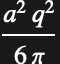

In [88]:
(* Larmor formula: P = \[Integral] (dP/d\[CapitalOmega]) d\[CapitalOmega] *)
Clear[\[Theta], \[Phi], a, q];
$Assumptions = {a > 0, q > 0, 0 <= \[Theta] <= Pi, 0 <= \[Phi] <= 2 Pi};

dPd\[CapitalOmega] = q^2 a^2 Sin[\[Theta]]^2 / (4 Pi)^2;
Print["dP/d\[CapitalOmega] = q^2 a^2 sin^2\[Theta] / (16\[Pi]^2)"];

Ptotal = FullSimplify[Integrate[dPd\[CapitalOmega] Sin[\[Theta]], {\[Theta], 0, Pi}, {\[Phi], 0, 2 Pi}]];
Print["P = ", Ptotal, "  = q^2 a^2/(6\[Pi])  Larmor formula  \[Checkmark]"];
Ptotal // TraditionalForm

-Graphics-
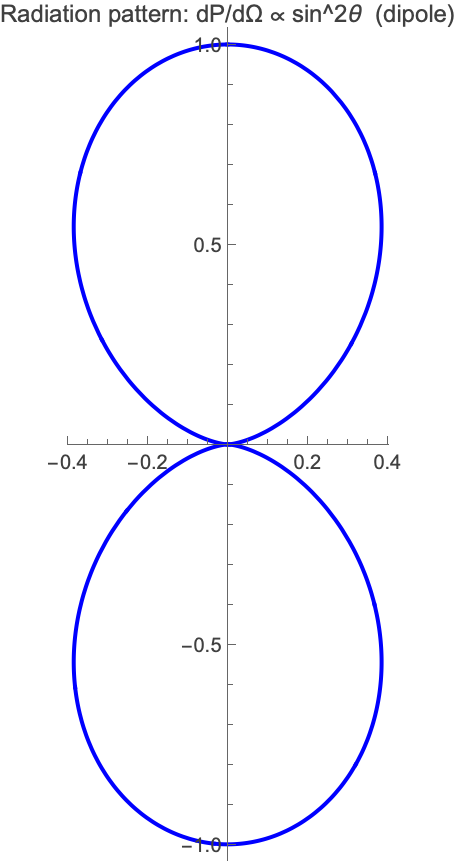

In [96]:
PolarPlot[Sin[\[Theta]]^2, {\[Theta], 0, 2 Pi},
  PlotLabel -> "Radiation pattern: dP/d\[CapitalOmega] \[Proportional] sin^2\[Theta]  (dipole)",
  PlotStyle -> Blue, ImageSize -> Medium]

---
## 8. Summary: M03 -> M04 bridge

```
Classical (M03)                    Quantum (M04)
-------------                    -------------
L = -1/4 F^2                ->   Z = int DA e^{iS}
Noether: T^{mu nu}, j^mu    ->   Ward identities
U(1) gauge symmetry         ->   Gauge fixing + FP ghosts
photon: 2 DOF               ->   D_F^{mu nu}(k)
Maxwell from E-L            ->   QED Feynman rules
```

**Key insight**: Gauge symmetry is NOT a physical symmetry - it is **descriptive redundancy**.

---
## Exercises

1. Derive $\partial_\mu F^{\mu\nu} = J^\nu$ from E-L (done)
2. Derive $T^{\mu\nu}$ via Noether (spacetime translation)
3. Prove $\mathcal{L}$ invariant under $U(1)$ gauge transform
4. Think: for $SU(3)$, why do we need $D_\mu = \partial_\mu - igA_\mu$? (M05 preview)